In [6]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

In [2]:
df = pd.read_csv("../upi_transactions_2024.csv")

In [9]:
df.head()



,transaction id,timestamp,transaction type,merchant_category,amount (INR),transaction_status,sender_age_group,receiver_age_group,sender_state,sender_bank,receiver_bank,device_type,network_type,fraud_flag,hour_of_day,day_of_week,is_weekend
0,TXN0000000001,2024-10-08 15:17:28,P2P,Entertainment,868,SUCCESS,26-35,18-25,Delhi,Axis,SBI,Android,4G,0,15,Tuesday,0
1,TXN0000000002,2024-04-11 06:56:00,P2M,Grocery,1011,SUCCESS,26-35,26-35,Uttar Pradesh,ICICI,Axis,iOS,4G,0,6,Thursday,0
2,TXN0000000003,2024-04-02 13:27:18,P2P,Grocery,477,SUCCESS,26-35,36-45,Karnataka,Yes Bank,PNB,Android,4G,0,13,Tuesday,0
3,TXN0000000004,2024-01-07 10:09:17,P2P,Fuel,2784,SUCCESS,26-35,26-35,Delhi,ICICI,PNB,Android,5G,0,10,Sunday,1
4,TXN0000000005,2024-01-23 19:04:23,P2P,Shopping,990,SUCCESS,26-35,18-25,Delhi,Axis,Yes Bank,iOS,WiFi,0,19,Tuesday,0


In [10]:
df.shape

(250000, 17)

In [11]:
df.columns

Index(['transaction id', 'timestamp', 'transaction type', 'merchant_category',
       'amount (INR)', 'transaction_status', 'sender_age_group',
       'receiver_age_group', 'sender_state', 'sender_bank', 'receiver_bank',
       'device_type', 'network_type', 'fraud_flag', 'hour_of_day',
       'day_of_week', 'is_weekend'],
      dtype='object')

In [12]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 250000 entries, 0 to 249999
Data columns (total 17 columns):
 #   Column              Non-Null Count   Dtype 
---  ------              --------------   ----- 
 0   transaction id      250000 non-null  object
 1   timestamp           250000 non-null  object
 2   transaction type    250000 non-null  object
 3   merchant_category   250000 non-null  object
 4   amount (INR)        250000 non-null  int64 
 5   transaction_status  250000 non-null  object
 6   sender_age_group    250000 non-null  object
 7   receiver_age_group  250000 non-null  object
 8   sender_state        250000 non-null  object
 9   sender_bank         250000 non-null  object
 10  receiver_bank       250000 non-null  object
 11  device_type         250000 non-null  object
 12  network_type        250000 non-null  object
 13  fraud_flag          250000 non-null  int64 
 14  hour_of_day         250000 non-null  int64 
 15  day_of_week         250000 non-null  object
 16  is

In [13]:
df.describe()

,amount (INR),fraud_flag,hour_of_day,is_weekend
count,250000.000000,250000.000000,250000.000000,250000.000000
mean,1311.756036,0.001920,14.681032,0.285348
std,1848.059224,0.043776,5.188304,0.451581
min,10.000000,0.000000,0.000000,0.000000
25%,288.000000,0.000000,11.000000,0.000000
50%,629.000000,0.000000,15.000000,0.000000
75%,1596.000000,0.000000,19.000000,1.000000
max,42099.000000,1.000000,23.000000,1.000000


In [14]:
df.isnull().sum()

transaction id        0
timestamp             0
transaction type      0
merchant_category     0
amount (INR)          0
transaction_status    0
sender_age_group      0
receiver_age_group    0
sender_state          0
sender_bank           0
receiver_bank         0
device_type           0
network_type          0
fraud_flag            0
hour_of_day           0
day_of_week           0
is_weekend            0
dtype: int64

In [15]:
df.duplicated().sum()

np.int64(0)

In [16]:
df['fraud_flag'].value_counts()

fraud_flag
0    249520
1       480
Name: count, dtype: int64

In [17]:
df['fraud_flag'].value_counts(normalize=True) * 100

fraud_flag
0    99.808
1     0.192
Name: proportion, dtype: float64

In [ ]:
COMPARING

In [20]:
df['transaction type'].value_counts()

transaction type
P2P             112445
P2M              87660
Bill Payment     37368
Recharge         12527
Name: count, dtype: int64

In [21]:
df.groupby('fraud_flag')['amount (INR)'].mean()

fraud_flag
0    1311.395391
1    1499.231250
Name: amount (INR), dtype: float64

In [22]:
df.groupby('fraud_flag')['amount (INR)'].median()

fraud_flag
0    629.0
1    618.5
Name: amount (INR), dtype: float64

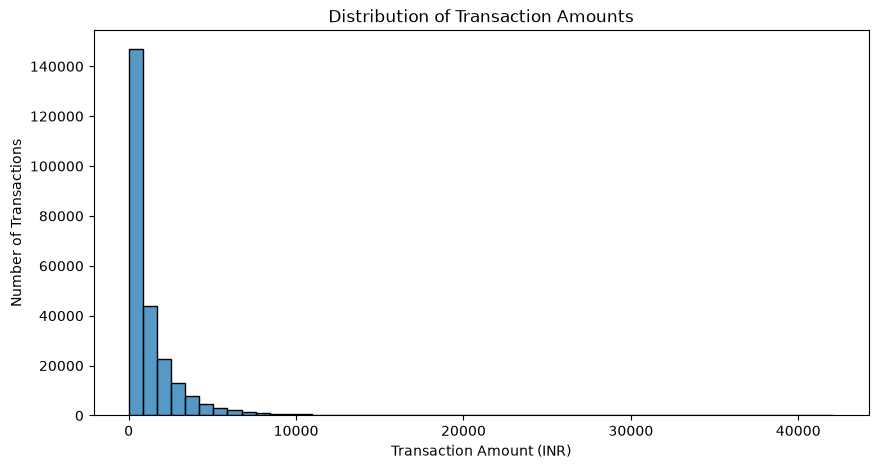

In [23]:
plt.figure(figsize=(10,5))

sns.histplot(data=df, x='amount (INR)', bins=50)

plt.title('Distribution of Transaction Amounts')
plt.xlabel('Transaction Amount (INR)')
plt.ylabel('Number of Transactions')

plt.show()

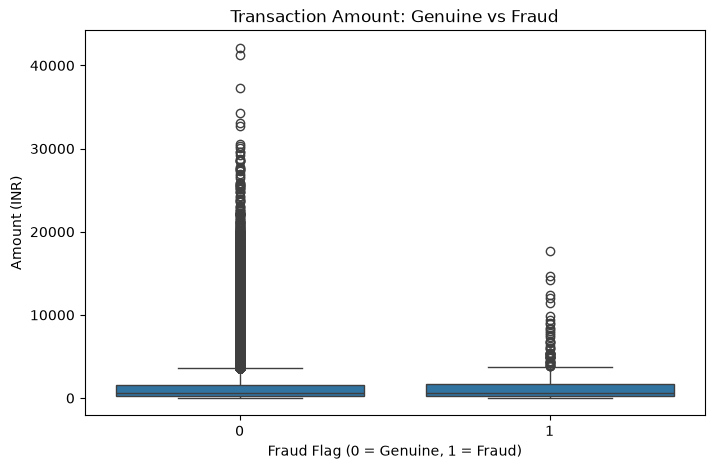

In [24]:
plt.figure(figsize=(8,5))

sns.boxplot(data=df, x='fraud_flag', y='amount (INR)')

plt.title('Transaction Amount: Genuine vs Fraud')
plt.xlabel('Fraud Flag (0 = Genuine, 1 = Fraud)')
plt.ylabel('Amount (INR)')

plt.show()

In [25]:
fraud_by_hour = df.groupby('hour_of_day')['fraud_flag'].mean() * 100

fraud_by_hour

hour_of_day
0     0.236128
1     0.267380
2     0.178042
3     0.304414
4     0.080192
5     0.057405
6     0.142816
7     0.230906
8     0.215595
9     0.191388
10    0.143843
11    0.165360
12    0.171272
13    0.166246
14    0.183054
15    0.253485
16    0.221555
17    0.201745
18    0.154506
19    0.202524
20    0.199935
21    0.215345
22    0.245622
23    0.154719
Name: fraud_flag, dtype: float64

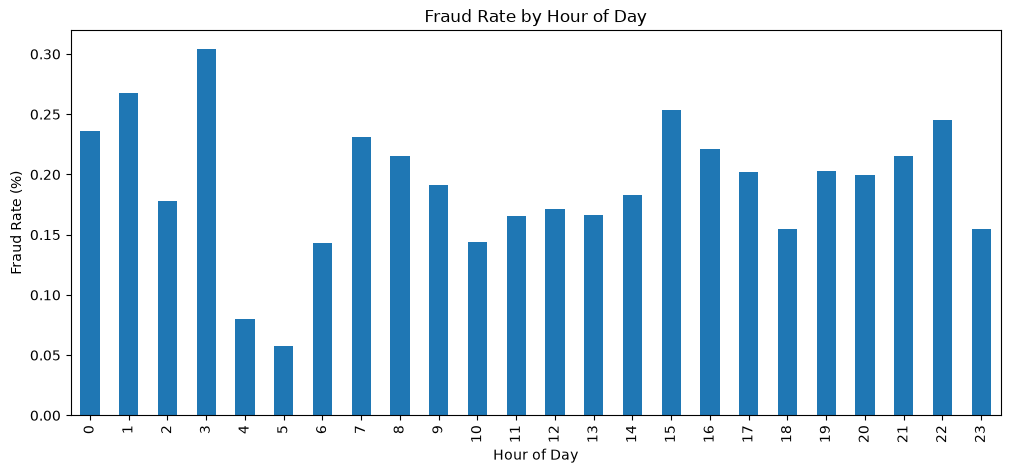

In [26]:
plt.figure(figsize=(12,5))

fraud_by_hour.plot(kind='bar')

plt.title('Fraud Rate by Hour of Day')
plt.xlabel('Hour of Day')
plt.ylabel('Fraud Rate (%)')

plt.show()

In [27]:
df.groupby('is_weekend')['fraud_flag'].mean() * 100

is_weekend
0    0.188623
1    0.200457
Name: fraud_flag, dtype: float64

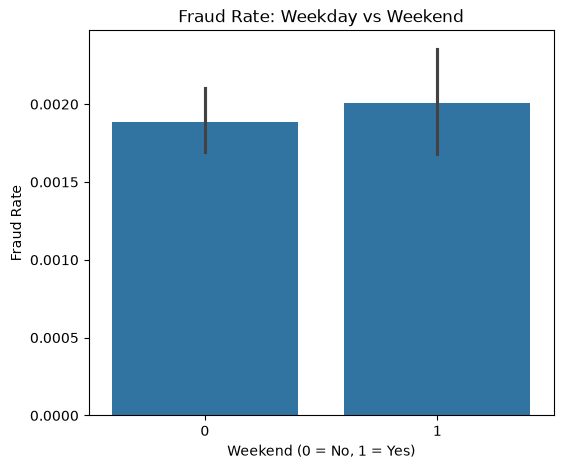

In [28]:
plt.figure(figsize=(6,5))

sns.barplot(
    data=df,
    x='is_weekend',
    y='fraud_flag'
)

plt.title('Fraud Rate: Weekday vs Weekend')
plt.xlabel('Weekend (0 = No, 1 = Yes)')
plt.ylabel('Fraud Rate')

plt.show()

In [30]:
df.groupby('hour_of_day')['fraud_flag'].mean() * 100

hour_of_day
0     0.236128
1     0.267380
2     0.178042
3     0.304414
4     0.080192
5     0.057405
6     0.142816
7     0.230906
8     0.215595
9     0.191388
10    0.143843
11    0.165360
12    0.171272
13    0.166246
14    0.183054
15    0.253485
16    0.221555
17    0.201745
18    0.154506
19    0.202524
20    0.199935
21    0.215345
22    0.245622
23    0.154719
Name: fraud_flag, dtype: float64

In [31]:
df.groupby('is_weekend')['fraud_flag'].mean() * 100

is_weekend
0    0.188623
1    0.200457
Name: fraud_flag, dtype: float64

In [32]:
df['transaction type'].value_counts()

transaction type
P2P             112445
P2M              87660
Bill Payment     37368
Recharge         12527
Name: count, dtype: int64

In [33]:
fraud_by_type = df.groupby('transaction type')['fraud_flag'].mean() * 100
fraud_by_type.sort_values(ascending=False)

transaction type
Recharge        0.239483
Bill Payment    0.206059
P2M             0.190509
P2P             0.183201
Name: fraud_flag, dtype: float64

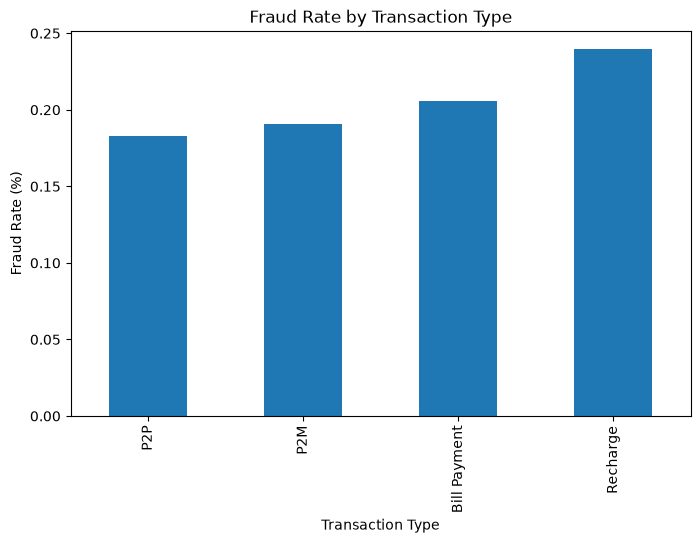

In [34]:
plt.figure(figsize=(8,5))

fraud_by_type.sort_values().plot(kind='bar')

plt.title('Fraud Rate by Transaction Type')
plt.xlabel('Transaction Type')
plt.ylabel('Fraud Rate (%)')

plt.show()

<Axes: xlabel='amount (INR)', ylabel='Density'>

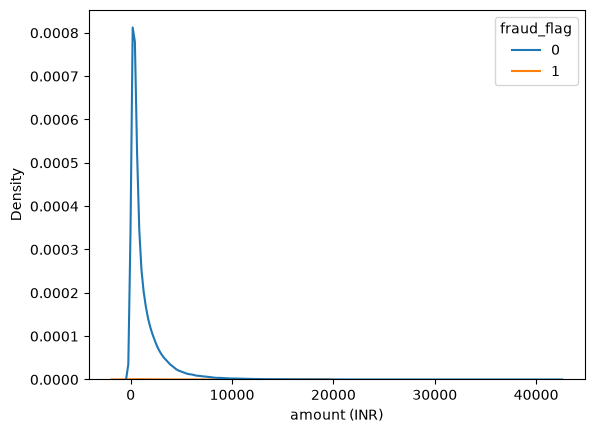

In [35]:
sns.kdeplot(
    data=df,
    x='amount (INR)',
    hue='fraud_flag'
)


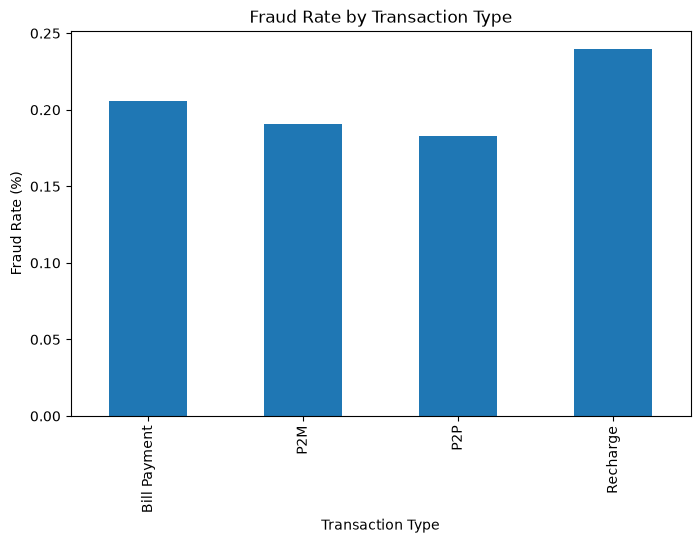

In [36]:
plt.figure(figsize=(8,5))

fraud_by_type.plot(kind='bar')

plt.title('Fraud Rate by Transaction Type')
plt.xlabel('Transaction Type')
plt.ylabel('Fraud Rate (%)')
plt.show()

In [40]:
df['merchant_category'].value_counts()

merchant_category
Grocery          49966
Food             37464
Shopping         29872
Fuel             25063
Other            24828
Utilities        22338
Transport        20105
Entertainment    20103
Healthcare       12663
Education         7598
Name: count, dtype: int64

In [41]:
df.groupby('merchant_category')['fraud_flag'].mean() * 100

merchant_category
Education        0.210582
Entertainment    0.198975
Food             0.194854
Fuel             0.191517
Grocery          0.188128
Healthcare       0.165837
Other            0.201386
Shopping         0.207552
Transport        0.213877
Utilities        0.147730
Name: fraud_flag, dtype: float64

In [42]:
df['sender_age_group'].value_counts()

sender_age_group
26-35    87432
36-45    62873
18-25    62345
46-55    24841
56+      12509
Name: count, dtype: int64

In [43]:
df.groupby('sender_age_group')['fraud_flag'].mean() * 100

sender_age_group
18-25    0.229369
26-35    0.186431
36-45    0.184499
46-55    0.124794
56+      0.215845
Name: fraud_flag, dtype: float64

In [45]:
df.groupby('receiver_age_group')['fraud_flag'].mean() * 100

receiver_age_group
18-25    0.210826
26-35    0.168442
36-45    0.201123
46-55    0.229626
56+      0.143415
Name: fraud_flag, dtype: float64

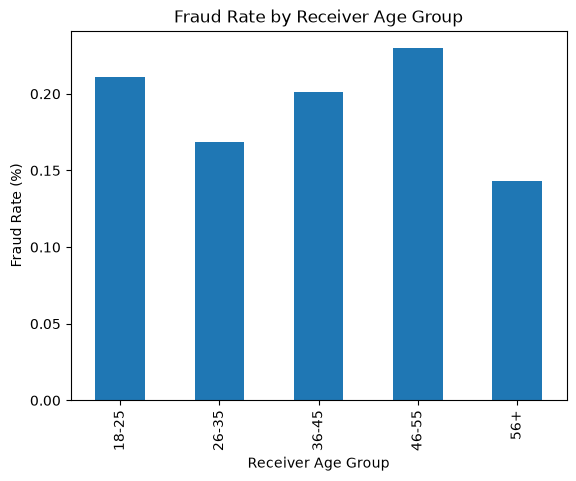

In [46]:
fraud_by_receiver_age = df.groupby('receiver_age_group')['fraud_flag'].mean() * 100

fraud_by_receiver_age.plot(kind='bar')

plt.title('Fraud Rate by Receiver Age Group')
plt.xlabel('Receiver Age Group')
plt.ylabel('Fraud Rate (%)')
plt.show()

In [47]:
df['sender_bank'].value_counts()

sender_bank
SBI         62693
HDFC        37485
ICICI       29769
IndusInd    25173
Axis        25042
PNB         24946
Yes Bank    24860
Kotak       20032
Name: count, dtype: int64

In [48]:
fraud_by_sender_bank = df.groupby('sender_bank')['fraud_flag'].mean() * 100
fraud_by_sender_bank

sender_bank
Axis        0.195671
HDFC        0.165399
ICICI       0.221707
IndusInd    0.206571
Kotak       0.249601
PNB         0.208450
SBI         0.173863
Yes Bank    0.160901
Name: fraud_flag, dtype: float64

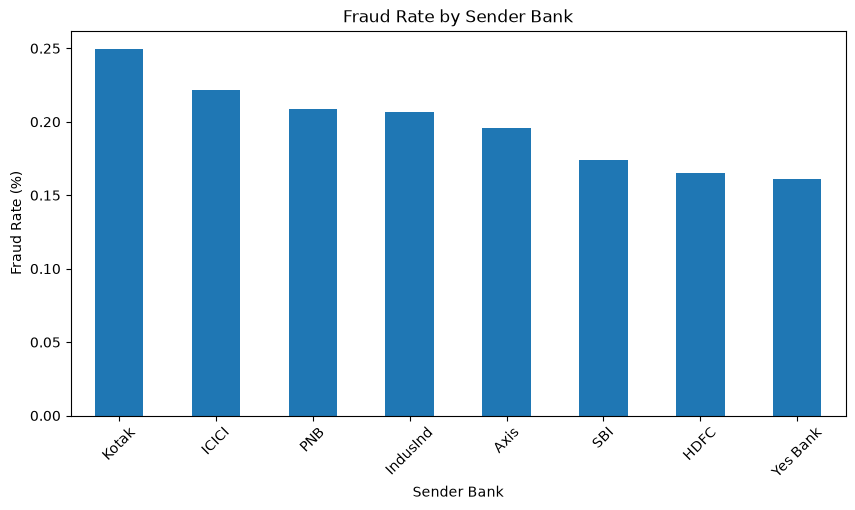

In [49]:
fraud_by_sender_bank.sort_values(ascending=False).plot(
    kind='bar',
    figsize=(10,5)
)

plt.title('Fraud Rate by Sender Bank')
plt.xlabel('Sender Bank')
plt.ylabel('Fraud Rate (%)')
plt.xticks(rotation=45)
plt.show()

In [50]:
df['receiver_bank'].value_counts()

receiver_bank
SBI         62378
HDFC        37651
ICICI       29944
IndusInd    25086
Yes Bank    25009
Axis        24992
PNB         24802
Kotak       20138
Name: count, dtype: int64

In [51]:
fraud_by_receiver_bank = df.groupby('receiver_bank')['fraud_flag'].mean() * 100
fraud_by_receiver_bank

receiver_bank
Axis        0.164052
HDFC        0.193886
ICICI       0.190355
IndusInd    0.207287
Kotak       0.203595
PNB         0.197565
SBI         0.185963
Yes Bank    0.203927
Name: fraud_flag, dtype: float64

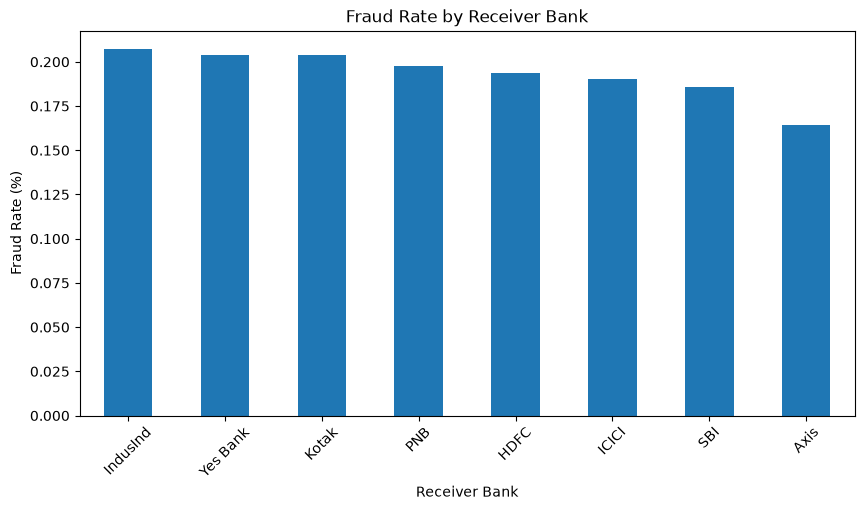

In [52]:
fraud_by_receiver_bank.sort_values(ascending=False).plot(
    kind='bar',
    figsize=(10,5)
)

plt.title('Fraud Rate by Receiver Bank')
plt.xlabel('Receiver Bank')
plt.ylabel('Fraud Rate (%)')
plt.xticks(rotation=45)
plt.show()

In [53]:
df['device_type'].value_counts()


device_type
Android    187777
iOS         49613
Web         12610
Name: count, dtype: int64

In [56]:
fraud_by_device = df.groupby('device_type')['fraud_flag'].mean() * 100
fraud_by_device 

device_type
Android    0.193847
Web        0.206186
iOS        0.181404
Name: fraud_flag, dtype: float64

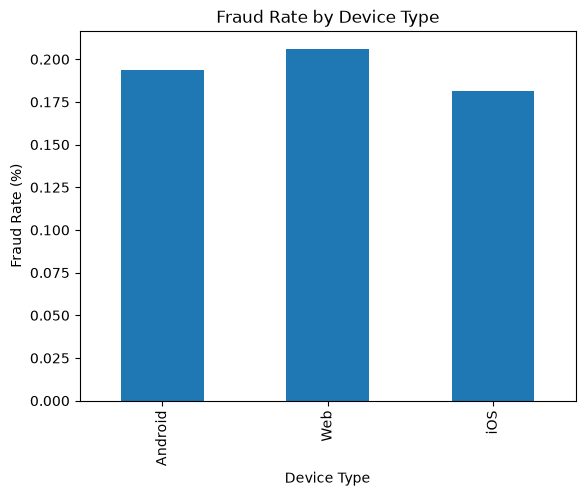

In [57]:
fraud_by_device.plot(kind='bar')

plt.title('Fraud Rate by Device Type')
plt.xlabel('Device Type')
plt.ylabel('Fraud Rate (%)')
plt.show()

In [58]:
df['network_type'].value_counts()

network_type
4G      149813
5G       62582
WiFi     25134
3G       12471
Name: count, dtype: int64

In [60]:
fraud_by_network = df.groupby('network_type')['fraud_flag'].mean() * 100
fraud_by_network

network_type
3G      0.192446
4G      0.188235
5G      0.183759
WiFi    0.234742
Name: fraud_flag, dtype: float64

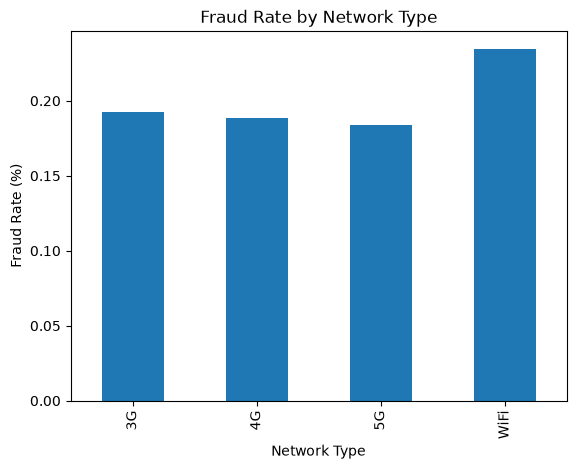

In [61]:
fraud_by_network.plot(kind='bar')

plt.title('Fraud Rate by Network Type')
plt.xlabel('Network Type')
plt.ylabel('Fraud Rate (%)')
plt.show()

In [62]:
df['day_of_week'].value_counts()

day_of_week
Monday       36495
Sunday       36003
Wednesday    35700
Tuesday      35540
Friday       35496
Thursday     35432
Saturday     35334
Name: count, dtype: int64

In [64]:
fraud_by_day = df.groupby('day_of_week')['fraud_flag'].mean() * 100
fraud_by_day

day_of_week
Friday       0.171850
Monday       0.194547
Saturday     0.192449
Sunday       0.208316
Thursday     0.203206
Tuesday      0.163196
Wednesday    0.210084
Name: fraud_flag, dtype: float64

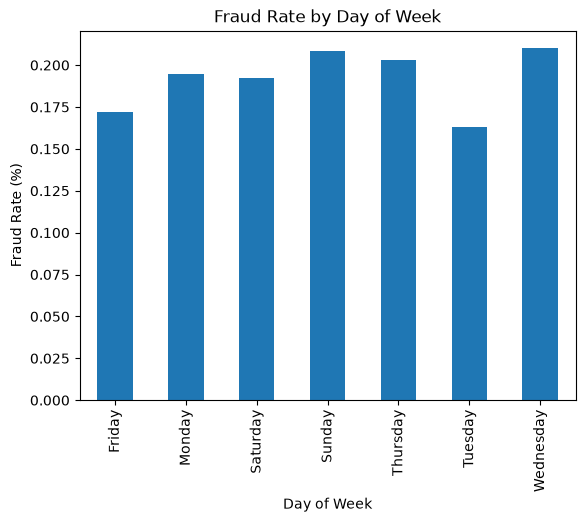

In [65]:
fraud_by_day.plot(kind='bar')

plt.title('Fraud Rate by Day of Week')
plt.xlabel('Day of Week')
plt.ylabel('Fraud Rate (%)')
plt.show()

In [66]:
df['fraud_flag'].value_counts(normalize=True) * 100

fraud_flag
0    99.808
1     0.192
Name: proportion, dtype: float64

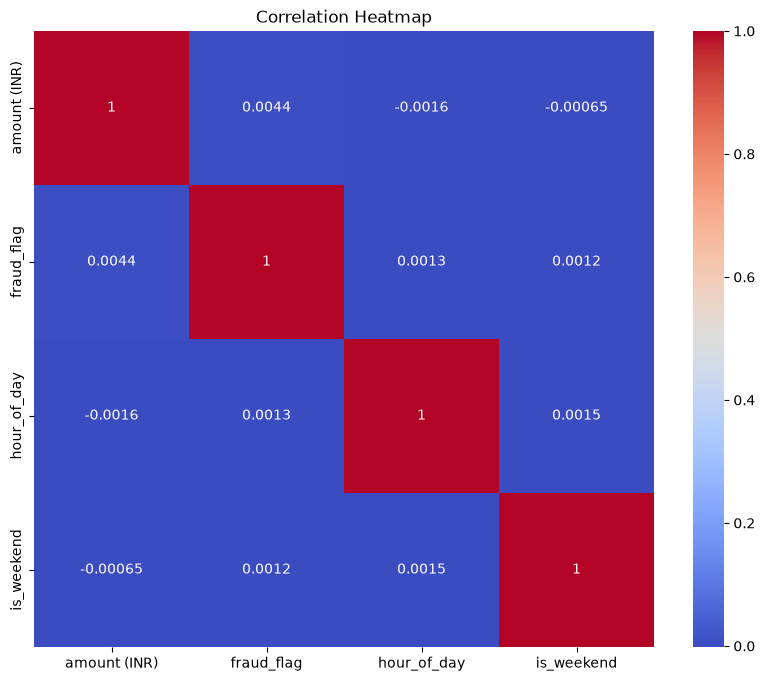

In [67]:
corr = df.select_dtypes(include='number').corr()

plt.figure(figsize=(10,8))
sns.heatmap(corr, annot=True, cmap='coolwarm')
plt.title('Correlation Heatmap')
plt.show()

In [68]:
df.groupby('sender_state')['fraud_flag'].mean() * 100

sender_state
Andhra Pradesh    0.174948
Delhi             0.201045
Gujarat           0.214346
Karnataka         0.231886
Maharashtra       0.189703
Rajasthan         0.230219
Tamil Nadu        0.157685
Telangana         0.173836
Uttar Pradesh     0.172614
West Bengal       0.175245
Name: fraud_flag, dtype: float64

In [ ]:
DATA CLEANING



In [69]:
df.isnull().sum()

transaction id        0
timestamp             0
transaction type      0
merchant_category     0
amount (INR)          0
transaction_status    0
sender_age_group      0
receiver_age_group    0
sender_state          0
sender_bank           0
receiver_bank         0
device_type           0
network_type          0
fraud_flag            0
hour_of_day           0
day_of_week           0
is_weekend            0
dtype: int64

In [70]:
df.duplicated().sum()

np.int64(0)